# 第007单元 代数函数与图像语言

这是完整顺序执行的标量实验。先修001、003，不需要NumPy、矩阵或微积分。先读lab.pdf并手算，再重启内核执行全部单元格。所有数据为原创合成教学例子；数值核验不代替数学证明。

In [1]:
from pathlib import Path
import csv, json, math, platform
import experiment as lab
assert Path("data/input_grid.csv").exists(), "请在本单元目录启动Notebook"
print("Python", platform.python_version())
print("标准库标量实验，无需GPU或网络")

Python 3.12.14
标准库标量实验，无需GPU或网络


## 三种方程情况

先求2x+1=7，再考虑a=0时的两种情况。只有非零a才能除以a。返回状态用来区分一个数值、全部实数与无解，不能用0冒充后两者。

In [2]:
for args in [(2, 1, 7), (0, 3, 3), (0, 3, 4)]:
    print(args, lab.solve_affine(*args))
assert lab.solve_affine(2, 1, 7)["value"] == 3

(2, 1, 7) {'kind': 'unique', 'value': 3.0}
(0, 3, 3) {'kind': 'all_real', 'value': None}
(0, 3, 4) {'kind': 'no_solution', 'value': None}


## 坐标点和任务范围

横轴是输入，纵轴是输出。先画出四个点。表达式的实数定义域与装置允许的[0,5]不同；不要把f(100)当作装置已经支持100格的证据。

In [3]:
points = [(x, lab.affine(x)) for x in [0, 1, 2, 3]]
print("绘图点", points)
assert points == [(0, 1), (1, 3), (2, 5), (3, 7)]
print("任务端点", lab.affine(0), lab.affine(5))
print("公式可算但任务未允许", lab.affine(100))

绘图点 [(0, 1), (1, 3), (2, 5), (3, 7)]
任务端点 1 11
公式可算但任务未允许 201


## 单位转换

厘米数值x与毫米数值u满足u=10x，所以替换x后斜率从2变成0.2。对同一物理长度，比较两种正确预测，再看错误保留系数的结果。

In [4]:
for cm in [1, 2, 3]:
    mm = 10 * cm
    original = lab.affine(cm)
    converted = lab.affine(mm, 0.2, 1)
    assert original == converted
    print({"cm": cm, "mm": mm, "original": original, "converted": converted, "wrong_coefficient": lab.affine(mm)})

{'cm': 1, 'mm': 10, 'original': 3, 'converted': 3.0, 'wrong_coefficient': 21}
{'cm': 2, 'mm': 20, 'original': 5, 'converted': 5.0, 'wrong_coefficient': 41}
{'cm': 3, 'mm': 30, 'original': 7, 'converted': 7.0, 'wrong_coefficient': 61}


## 指数与对数反读

负指数表示倒数；对数的负输出不要求负输入。最后两个值检查括号对幂运算的影响。

In [5]:
for x in [-2, -1, 0, 1, 2, 3]:
    y = lab.power_two(x)
    recovered = lab.real_log(y)
    assert abs(recovered - x) < 1e-12
    print(x, y, recovered)
print("负底数平方、平方后取负", (-2) ** 2, -2 ** 2)
print("底数1/2时", lab.real_log(2, 0.5), lab.real_log(4, 0.5))

-2 0.25 -2.0
-1 0.5 -1.0
0 1.0 0.0
1 2.0 1.0
2 4.0 2.0
3 8.0 3.0
负底数平方、平方后取负 4 -4
底数1/2时 -1.0 -2.0


## 恒等式与一个反例

乘积取对数成为和，和取对数却通常不等于对数的和。换底与幂律都需正输入及合法底数，详细推导在讲义。这里的1e-12仅用于本组小数值。

In [6]:
product = lab.real_log(4 * 8)
sum_logs = lab.real_log(4) + lab.real_log(8)
assert abs(product - sum_logs) < 1e-12
assert abs(lab.real_log(4 ** 3) - 3 * lab.real_log(4)) < 1e-12
assert abs(lab.real_log(8, 10) - math.log10(8)) < 1e-12
print("乘积公式", product, sum_logs)
print("加法反例", lab.real_log(4 + 4), lab.real_log(4) + lab.real_log(4))

乘积公式 5.0 5.0
加法反例 3.0 4.0


## 操作顺序改变目标

A=[1,9]与B=[4,4]均为两条正损失，越小越好。分别核对原平均、整体取对数、逐项取对数再平均。第三种相当于比较几何平均的对数，因而与算术平均不等价。

In [7]:
summaries = {name: lab.positive_loss_summary(values) for name, values in [("A", [1, 9]), ("B", [4, 4])]}
print(json.dumps(summaries, indent=2))
winners = {metric: min(summaries, key=lambda name: summaries[name][metric]) for metric in ["mean", "log2_of_mean", "mean_of_log2"]}
assert winners == {"mean": "B", "log2_of_mean": "B", "mean_of_log2": "A"}
print("各目标选择", winners)

{
  "A": {
    "mean": 5.0,
    "log2_of_mean": 2.321928094887362,
    "mean_of_log2": 1.5849625007211563
  },
  "B": {
    "mean": 4.0,
    "log2_of_mean": 2.0,
    "mean_of_log2": 2.0
  }
}
各目标选择 {'mean': 'B', 'log2_of_mean': 'B', 'mean_of_log2': 'A'}


## 求和与复合逐步追踪

先写出中间结果，避免误读括号。分段函数在0有定义；其尖角不能被解释为没有函数值。

In [8]:
values = [2, 4, 6]
print("逐项加1求和、原和加1", sum(x + 1 for x in values), sum(values) + 1)
print("先平方再仿射", lab.affine(lab.square(2)))
print("先仿射再平方", lab.square(lab.affine(2)))
print("分段边界", [(x, lab.rectifier(x)) for x in [-2, 0, 3]])
assert lab.real_log(2 - 1) == 0
assert [lab.rectifier(x) for x in [-2, 0, 3]] == [0, 0, 3]

逐项加1求和、原和加1 15 13
先平方再仿射 9
先仿射再平方 25
分段边界 [(-2, 0), (0, 0), (3, 3)]


## 两类失败须分开报告

前两项违反实数对数定义域。后两项在实数数学中有正值，但浮点表示超出可用范围。所有异常都在预期分支被捕获；不把失败输出当成0。

In [9]:
for function, value in [(lab.real_log, -1), (lab.real_log, 0), (lab.power_two, 1024), (lab.power_two, -1075)]:
    try:
        function(value)
    except (ValueError, ArithmeticError) as error:
        print(function.__name__, value, type(error).__name__)
    else:
        raise AssertionError("预期的错误未被拒绝")

real_log -1 ValueError
real_log 0 ValueError
power_two 1024 ArithmeticError
power_two -1075 ArithmeticError


## 保存可追查的结果

CSV空白只用于未定义的对数，并有状态列说明。请比较x=0行与x=1行，区分没有定义与真正的数值0。

In [10]:
report = lab.run()
with open("outputs/function_values.csv", newline="", encoding="utf-8") as stream:
    rows = list(csv.DictReader(stream))
for row in rows:
    print(row)
assert len(rows) == 10
print("JSON目标选择", report["objective_winners"])

{'x': '-2.0', 'affine_2x_plus_1': '-3.0', 'square': '4.0', 'power_2': '0.25', 'rectifier': '0', 'log2': '', 'log2_status': 'outside_real_domain'}
{'x': '-1.0', 'affine_2x_plus_1': '-1.0', 'square': '1.0', 'power_2': '0.5', 'rectifier': '0', 'log2': '', 'log2_status': 'outside_real_domain'}
{'x': '0.0', 'affine_2x_plus_1': '1.0', 'square': '0.0', 'power_2': '1.0', 'rectifier': '0.0', 'log2': '', 'log2_status': 'outside_real_domain'}
{'x': '0.25', 'affine_2x_plus_1': '1.5', 'square': '0.0625', 'power_2': '1.189207115002721', 'rectifier': '0.25', 'log2': '-2.0', 'log2_status': 'defined'}
{'x': '0.5', 'affine_2x_plus_1': '2.0', 'square': '0.25', 'power_2': '1.4142135623730951', 'rectifier': '0.5', 'log2': '-1.0', 'log2_status': 'defined'}
{'x': '1.0', 'affine_2x_plus_1': '3.0', 'square': '1.0', 'power_2': '2.0', 'rectifier': '1.0', 'log2': '0.0', 'log2_status': 'defined'}
{'x': '2.0', 'affine_2x_plus_1': '5.0', 'square': '4.0', 'power_2': '4.0', 'rectifier': '2.0', 'log2': '1.0', 'log2_sta

## 自动检查与反思

测试含100组精确Fraction根值、定义域错误、浮点范围失败及独立子进程调用。通过仅说明当前实现符合这些约定；它不是对全部实数输入稳定性的证明。用你自己的话说明为何A和B的第三种目标交换排名。

In [11]:
from test_experiment import run_tests
tests = run_tests()
print(json.dumps(tests, indent=2))
assert tests["status"] == "passed"
assert len(tests["test_groups"]) == 11

{
  "status": "passed",
  "test_groups": [
    "three equation cases and 100 independent Fraction roots",
    "unit-conversion invariance and incorrect-coefficient counterexample",
    "integer powers, negative exponents and Python precedence",
    "logarithm known values and invalid domains",
    "product-log identity and sum-log counterexample",
    "ranking reversal only for per-item log before averaging",
    "composition order, composition domain and piecewise boundary",
    "summation expansion and byte-identical repeat outputs",
    "type, empty-data, nonfinite, overflow and underflow failures",
    "power and change-of-base laws; decreasing logarithm for base below one",
    "fresh process from unrelated directory and explicit undefined-value CSV status"
  ]
}


## 对照已有图像

下面图像由make_figures.py独立重建。普通坐标上的四个小图具有各自纵轴范围，比较时读坐标数值。你的手绘点应与相应函数一致。

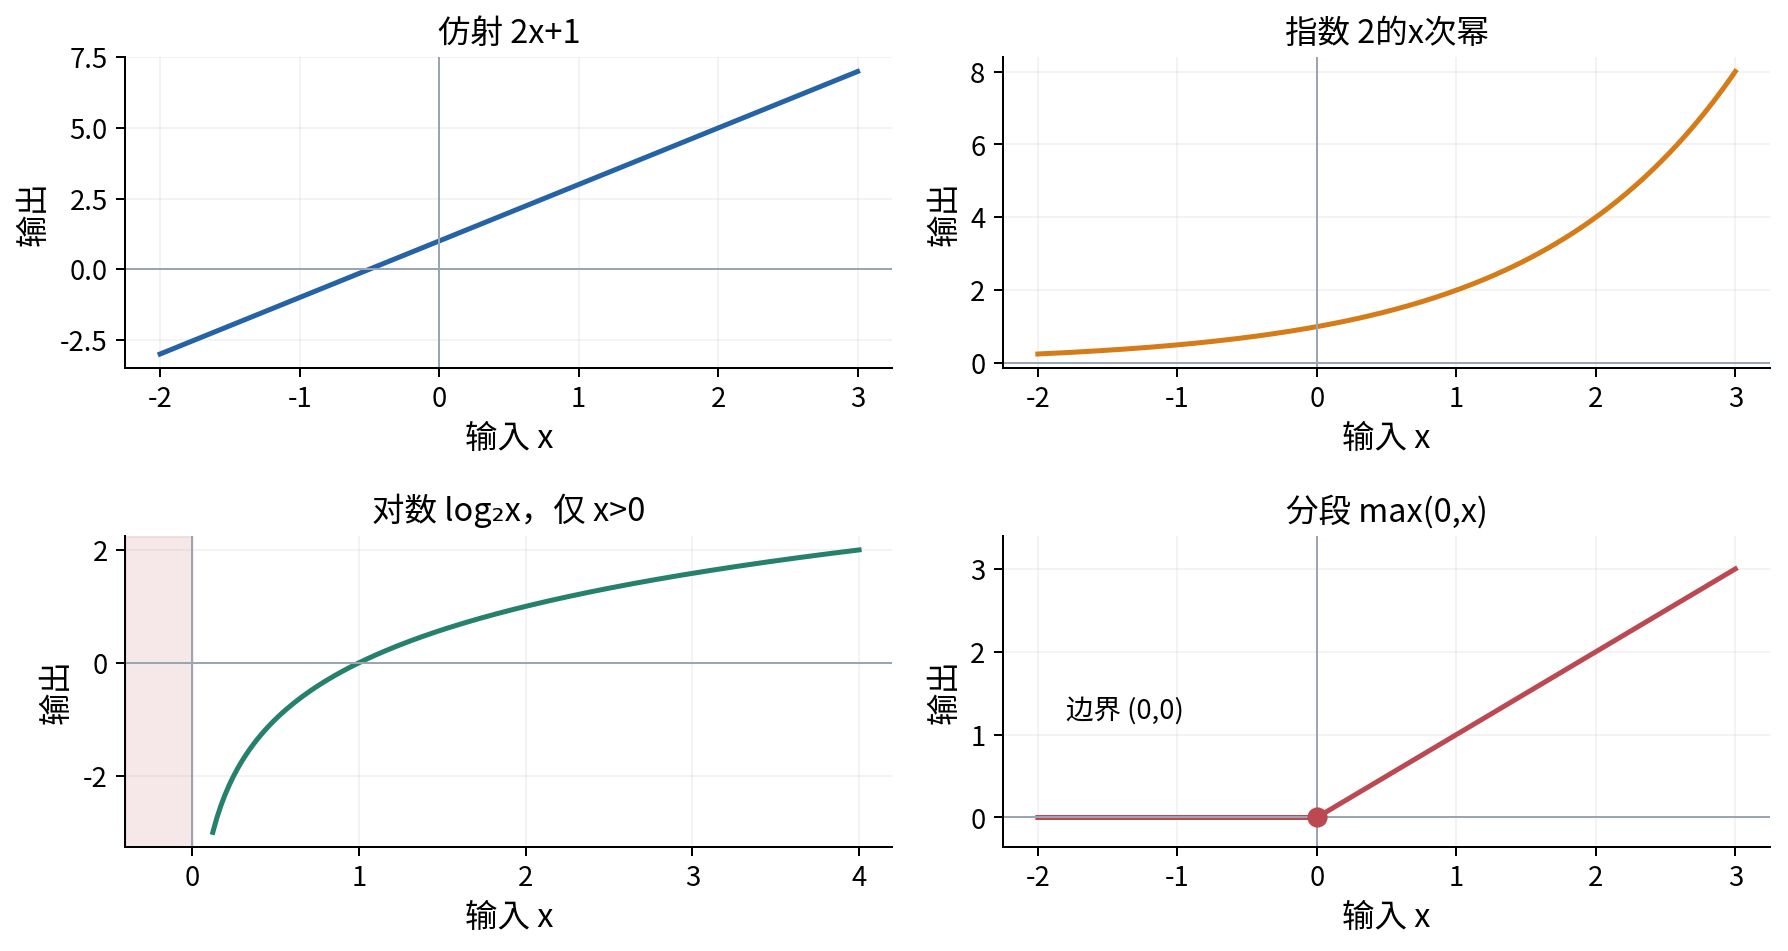

In [12]:
from IPython.display import Image, display
display(Image(filename="figures/08_function_family.png"))